In [54]:
# Import the necessary libraries
import numpy as np
import matplotlib.pyplot as plt
import scipy.interpolate as spi

In [55]:
# TeX fonts for plots
plt.rc('text', usetex=True)
plt.rc('font', family='serif')

In [56]:
# Initialization
betta = 0.95
alpha = 0.3
delta = 0.1
sigma = 2.0
maxiter = 10000

In [57]:
# markov chain
nz = 3
z = np.array([0.75, 1.0, 1.25])
P = np.array([[0.25, 0.65, 0.1],
              [0.1, 0.8, 0.1],
              [0.01, 0.75, 0.24]])

In [58]:
# Create a grid for K
k_min = 1.0
k_max = 15.0
nk = 1000

kgrid = np.linspace(k_min,k_max,nk)

In [59]:
# Preallocation

v_guess = np.zeros((nk, nz))
val = np.zeros((nk, nz))
v_new = np.zeros((nk, nz))
kprime = np.zeros((nk, nz))
kp_ind = np.zeros((nk, nz),dtype=int)


# The main loop

for iter1 in range(maxiter):

    for ik in range(nk):
        
        for iz in range(nz):

            kp_con_all = np.where(kgrid>=(1-delta)*kgrid[ik])[0]
            kp_con = kp_con_all[0]

            # Calculate for each k' the RHS of the Bellman equation

            con = z[iz] * kgrid[ik]**alpha + (1-delta)*kgrid[ik] - kgrid[kp_con:]

            # 2) Check if consumption is positive; if not, assign a large negative value
            con_i = (con>0.0)*(con**(1.0-sigma)-1.0)/(1.0-sigma)+(con<=0.0)*(-10000000.0)

            # 3) Calculate the implied value
            val = con_i + betta*np.sum(P[iz, np.newaxis, :] * v_guess[kp_con:, :], axis=1)

            # 4) The new V for a given k is then the maximum value from 3)
            v_new[ik, iz] = np.amax(val)

            # 5) Determine the respective k' choice (using np.argmax e.g.)
            kp_ind[ik, iz] = np.argmax(val)+kp_con
            kprime[ik, iz] = kgrid[kp_ind[ik, iz]]

    # Calculate the distance as the maximum of the absolute difference
    # between your old guess and the obtained function values
    metric = np.amax(np.abs(v_guess-v_new))

    # You may want to print your metric to see if the algorithm converges
    #print(iter1,metric)

    # Check for convergence
    if metric<1e-5:
        break

    # Set the new guess for V
    v_guess[:, :] = v_new[:, :]

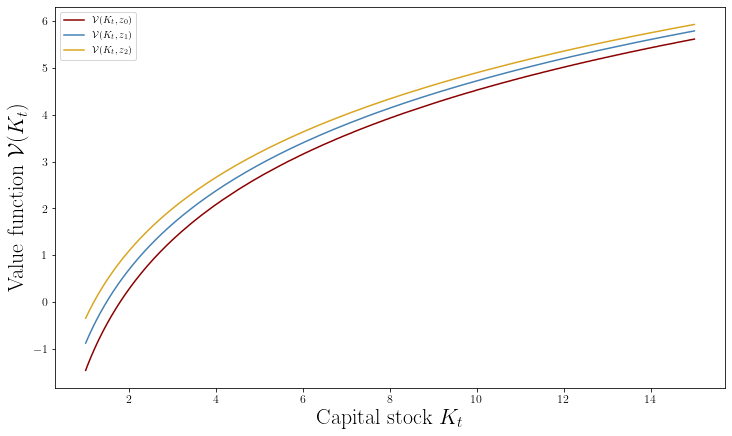

In [60]:
# Plot the resulting value function
fig, ax = plt.subplots(figsize=(12,7))
ax.plot(kgrid, v_guess[:, 0], label='$\mathcal{V}(K_t, z_0)$', color='darkred')
ax.plot(kgrid, v_guess[:, 1], label='$\mathcal{V}(K_t, z_1)$', color='steelblue')
ax.plot(kgrid, v_guess[:, 2], label='$\mathcal{V}(K_t, z_2)$', color='goldenrod')
ax.set_ylabel("Value function $\mathcal{V}(K_t)$", fontsize=22)
ax.set_xlabel("Capital stock $K_t$", fontsize=22)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
plt.legend()
plt.show()
#fig.savefig("name_of_this_plot.pdf", bbox_inches='tight')

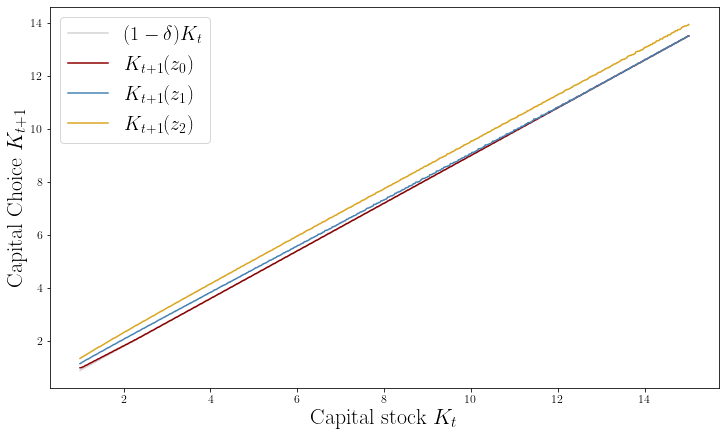

In [61]:
# Plot the resulting policy function
fig, ax = plt.subplots(figsize=(12,7))
ax.plot(kgrid, (1-delta)*kgrid, label="$(1-\\delta)K_t$",color='lightgrey')
ax.plot(kgrid, kprime[:, 0], label='$K_{t+1}(z_0)$', color='darkred')
ax.plot(kgrid, kprime[:, 1], label='$K_{t+1}(z_1)$', color='steelblue')
ax.plot(kgrid, kprime[:, 2], label='$K_{t+1}(z_2)$', color='goldenrod')
ax.set_ylabel("Capital Choice $K_{t+1}$", fontsize=22)
ax.set_xlabel("Capital stock $K_t$", fontsize=22)
ax.tick_params(axis="x", labelsize=12)
ax.tick_params(axis="y", labelsize=12)
ax.legend(loc='best',fontsize=20)
plt.show()
#fig.savefig("name_of_this_plot.pdf", bbox_inches='tight')